In [7]:
import pandas as pd
import numpy as np
import datetime
import glob
import os

In [8]:
# Function to apply formatting rules
def format_column_names(indexes):
    formatted_indexes = []
    for index in indexes:
        # Replace spaces with "_" outside of parentheses
        outside, *inside = index.split('(')
        outside_formatted = outside.replace(' ', '_')
        if inside:  # Check if there is a part inside parentheses
            inside_formatted = '('.join(inside).replace(' ', '')  # Remove space inside parentheses
            formatted_index = f"{outside_formatted}({inside_formatted}"
        else:
            formatted_index = outside_formatted
        # Remove brackets and replace "(" with "_"
        formatted_index = formatted_index.replace('(', '_').replace(')', '')
        formatted_indexes.append(formatted_index)
    return formatted_indexes

def clean_column_names():
    # Specify the directory path
    directory_path = '/workspaces/CUBES/exp/jack/Data/LEEDR/LEEDR_data_minute_pir/csv_schedules'

    # Get all directories within the specified directory
    directories = [d for d in os.listdir(directory_path) if os.path.isdir(os.path.join(directory_path, d))]

    # Iterate through each directory
    for directory in directories:
        limits = [1,2,5]
        for lim in limits:
            # Construct the path to the CSV file within the current directory
            filename = directory + "_" + str(lim) + "_schedule.csv"

            csv_file_path = os.path.join(directory_path, directory, filename)

            # Check if the CSV file exists
            if os.path.exists(csv_file_path):
                # Open the CSV file using pandas
                df = pd.read_csv(csv_file_path, index_col = 0)

                index_labels = df.columns

                index_labels = [label.strip('"') for label in index_labels]

                index_labels = format_column_names(index_labels)

                df.columns = index_labels

                df.to_csv(csv_file_path)

            else:
                print(f"No CSV file found in {directory}")

    return

In [2]:
def clean_column_names():
    # Specify the directory path
    directory_path = '/workspaces/CUBES/exp/jack/Data/LEEDR/LEEDR_data_minute_pir/csv_schedules'

    # Get all directories within the specified directory
    directories = [d for d in os.listdir(directory_path) if os.path.isdir(os.path.join(directory_path, d))]

    # Iterate through each directory
    for directory in directories:
        limits = [1,2,5]
        for lim in limits:
            # Construct the path to the CSV file within the current directory
            filename = directory + "_" + str(lim) + "_schedule.csv"

            csv_file_path = os.path.join(directory_path, directory, filename)

            # Check if the CSV file exists
            if os.path.exists(csv_file_path):
                # Open the CSV file using pandas
                df = pd.read_csv(csv_file_path, index_col = 0)

                index_labels = df.columns

                index_labels = [label.strip('"') for label in index_labels]

                df.columns = index_labels

                df.to_csv(csv_file_path)

            else:
                print(f"No CSV file found in {directory}")

    return

In [70]:
cwd = os.getcwd()
pir_data_path = os.path.dirname(cwd)

# I will need to get all of the data

def get_raw_pir_data():
    pir_files = []
    for file in glob.glob(os.path.join(pir_data_path, "*CLEAN.txt")):
        pir_files.append(file)
    pir_files = sorted(pir_files)

    head_files = []
    for file in glob.glob(os.path.join(pir_data_path, "*.head")):
        head_files.append(file)
    head_files = sorted(head_files)

    return pir_files, head_files


def check_zone_data_coverage(dataframe):
    positive_counts = (dataframe >=0).sum()
    total_steps = len(dataframe)

    coverage = positive_counts/total_steps

    list_coverage = coverage.to_list()

    return list_coverage

# get raw pir into a usable format with correct columns names

def format_pir_data(pir_files, head_files):


    data_dict = {"dataframe":[]}

    for i, file in enumerate(pir_files):

        house_id = file.split("-")[1]

        data = pd.read_csv(file, sep=" ", header=None, index_col=0)

        #data = data.iloc[::5]

        with open(head_files[i], 'r') as f:
            lines = f.readlines()

        column_names = lines[-1].split('\t')
        column_names = column_names[0].split("   ")


        if column_names[-1] == " ":
            del column_names[-1]

        rename = column_names[2:]
        new_cols = column_names[:2]

        for col in rename:
            col = house_id + "_" + col.split(",")[-1]
            new_cols.append(col)

        data.columns = new_cols

        data['UTC_Time'] = pd.to_datetime(data['unixtime'], unit='s', origin='unix')
        data = data.drop(columns=['unixtime', 'unixtimeDST'])
        data = data.set_index("UTC_Time")

        zone_data_coverage = check_zone_data_coverage(data)

        # Collect columns to drop
        columns_to_drop = []

        for i, coverage in enumerate(zone_data_coverage):
            if coverage < 0.8:
                # Append the column name to the list of columns to drop
                columns_to_drop.append(data.columns[i])

        # Drop the columns outside the loop
        data_dropped = data.drop(columns=columns_to_drop, axis=1)

        if len(data_dropped.columns) > 0:
            data_dict["dataframe"].append(data_dropped)

    return data_dict


# Function to generate priority datetime offsets
def generate_datetime_priorities(base_datetime):
    offsets = [
        pd.DateOffset(years=0),  # same year
        pd.DateOffset(years=1),  # next year
        pd.DateOffset(years=-1),  # previous year
        pd.DateOffset(months=-1),  # previous month, same year
        pd.DateOffset(months=1),  # next month, same year
        pd.DateOffset(years=-1, months=-1),  # previous year, previous month
        pd.DateOffset(years=-1, months=1),  # previous year, next month
        pd.DateOffset(years=1, months=-1),  # next year, previous month
        pd.DateOffset(years=1, months=1),  # next year, next month
    ]
    return [base_datetime + offset for offset in offsets]


def replace_missing_data(df):
    print("df: ", df)
    print("house id: ", df.columns[0].split("_"))
    print("df type: ", type(df))
    replacement_error = {"id":[],
                         "index": []}

    # Replace -99 with NaN for easier handling
    df.replace(-99, np.nan, inplace=True)

    # Iterate over the DataFrame to find and replace NaN values
    for (row_index, row) in df.iterrows():
        for col in df.columns:
            if pd.isnull(row[col]):  # If the value is NaN (originally -99)
                datetime_priorities = generate_datetime_priorities(row_index)

                # Attempt to find a replacement value
                replacement_found = False
                for priority_datetime in datetime_priorities:
                    if priority_datetime in df.index:
                        replacement_value = df.at[priority_datetime, col]
                        if not pd.isnull(replacement_value):
                            df.at[row_index, col] = replacement_value
                            replacement_found = True
                            break

                if not replacement_found:
                    replacement_error["id"].append(df.columns[0].split("_"))
                    replacement_error["index"].append(row_index)
                    # Optional: Handle the case where no replacement is found, e.g., keep as NaN or set a default value
                    pass

    return df, replacement_error

def resample_pir(dataframe, limit):
    resampled_df = dataframe.resample('10T').apply(lambda x: 1 if (x != 0).sum() >= limit else 0)

    return resampled_df

def load_pir_csv_file():
    csv_files = []
    for file in glob.glob("*.csv"):
        csv_files.append(file)
    csv_files = sorted(csv_files)
    return csv_files


def main():
    csv_files = load_pir_csv_file()
    print(csv_files)
    resampling_values = [1,2,5]

    p, h = get_raw_pir_data()
    df_dict = format_pir_data(p, h)

    for i, csv in enumerate(csv_files[:1]):

        df = pd.read_csv(csv)

        df.index = df_dict["dataframe"][i].index

        house_id = df.columns[0].split("_")[0]

        os.makedirs(house_id)

        for r_v in resampling_values[:1]:
            resampled_df = resample_pir(df, r_v)

            file_path = os.path.join(house_id, "{}_{}_{}.csv".format(house_id, r_v, "schedule"))

            resampled_df.to_csv(file_path)

    return

#def main():
#    p, h = get_raw_pir_data()
#    df = format_pir_data(p, h)
#
#    for fd in df["dataframe"]:
#        replaced_fd, replacement_error = replace_missing_data(fd)
#        house_id = df.columns[0].split("_")
#        replaced_fd.to_csv(house_id+".csv", index=False, sep=',', encoding='utf-8', header=True)
#
#    return




In [71]:
main()

['H05.csv', 'H08.csv', 'H09.csv', 'H10.csv', 'H18.csv', 'H28.csv', 'H33.csv', 'H37.csv', 'H38.csv', 'H39.csv', 'H40.csv', 'H41.csv', 'H42.csv', 'H43.csv', 'H45.csv', 'H46.csv']


/tmp/ipykernel_70828/4007265470.py:138: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_df = dataframe.resample('10T').apply(lambda x: 1 if (x != 0).sum() >= limit else 0)


: 

In [44]:
csv = load_pir_csv_file()

In [45]:
csv

['H05.csv',
 'H08.csv',
 'H09.csv',
 'H10.csv',
 'H18.csv',
 'H28.csv',
 'H33.csv',
 'H37.csv',
 'H38.csv',
 'H39.csv',
 'H40.csv',
 'H41.csv',
 'H42.csv',
 'H43.csv',
 'H45.csv',
 'H46.csv']

In [36]:
p, h = get_raw_pir_data()
df = format_pir_data(p, h)

In [64]:
df["dataframe"][-1].index

DatetimeIndex(['2012-06-20 00:00:00', '2012-06-20 00:01:00',
               '2012-06-20 00:02:00', '2012-06-20 00:03:00',
               '2012-06-20 00:04:00', '2012-06-20 00:05:00',
               '2012-06-20 00:06:00', '2012-06-20 00:07:00',
               '2012-06-20 00:08:00', '2012-06-20 00:09:00',
               ...
               '2014-06-30 23:50:00', '2014-06-30 23:51:00',
               '2014-06-30 23:52:00', '2014-06-30 23:53:00',
               '2014-06-30 23:54:00', '2014-06-30 23:55:00',
               '2014-06-30 23:56:00', '2014-06-30 23:57:00',
               '2014-06-30 23:58:00', '2014-06-30 23:59:00'],
              dtype='datetime64[ns]', name='UTC_Time', length=1067040, freq=None)

In [16]:
h46 = pd.read_csv("H46.csv")
h46

,"H46_Backroom(Down stairs)""","H46_Utility(Down stairs)""","H46_Bedroom 4(Upstairs)""","H46_Bathroom 1(Upstairs)""","H46_Bedroom 5(Upstairs)""","H46_Front Room(Down stairs)""","H46_Hall(Down stairs)""","H46_Bedroom 2(Upstairs)""","H46_Kitchen(Down stairs)""","H46_Bedroom 1(Upstairs)""","H46_Bedroom 3(Upstairs)"""
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1067035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1067036,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1067037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1067038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
h46.index = df["dataframe"][-1].index

In [19]:
h46

,"H46_Backroom(Down stairs)""","H46_Utility(Down stairs)""","H46_Bedroom 4(Upstairs)""","H46_Bathroom 1(Upstairs)""","H46_Bedroom 5(Upstairs)""","H46_Front Room(Down stairs)""","H46_Hall(Down stairs)""","H46_Bedroom 2(Upstairs)""","H46_Kitchen(Down stairs)""","H46_Bedroom 1(Upstairs)""","H46_Bedroom 3(Upstairs)"""
UTC_Time,,,,,,,,,,,
2012-06-20 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012-06-20 00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012-06-20 00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012-06-20 00:03:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012-06-20 00:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2014-06-30 23:55:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-06-30 23:56:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-06-30 23:57:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# Resampling data into 10-minute intervals and checking for non-zero entries
new_df = h46.resample('10T').apply(lambda x: 1 if (x != 0).any() else 0)

/tmp/ipykernel_18746/1087515609.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  new_df = h46.resample('10T').apply(lambda x: 1 if (x != 0).any() else 0)


In [24]:
new_df["H46_Kitchen(Down stairs)\""].iloc[:10000]

UTC_Time
2012-06-20 00:00:00    0
2012-06-20 00:10:00    0
2012-06-20 00:20:00    0
2012-06-20 00:30:00    0
2012-06-20 00:40:00    0
                      ..
2012-08-28 09:50:00    1
2012-08-28 10:00:00    0
2012-08-28 10:10:00    0
2012-08-28 10:20:00    0
2012-08-28 10:30:00    0
Freq: 10min, Name: H46_Kitchen(Down stairs)", Length: 10000, dtype: int64

<Axes: xlabel='UTC_Time'>

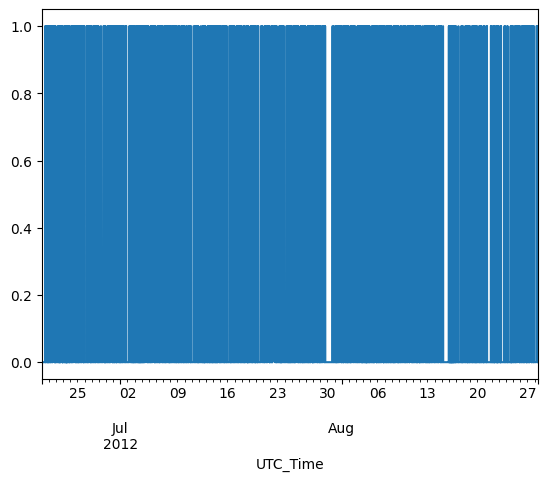

In [25]:
new_df["H46_Kitchen(Down stairs)\""].iloc[:10000].plot()